# *MICE for CATS* Replication Code
This python notebook replicates the methods in the *MICE for Cats* paper but modifies the code to fit in the application of Abstain/Clarify/Answer scenario.

### Setup

In [ ]:
!pip install transformers accelerate huggingface-hub bert-score
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
import pandas as pd
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_from_disk
from bert_score import BERTScorer
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata

In [ ]:
# drive allocation
import os
from google.colab import drive
from datasets import load_dataset, Dataset, load_from_disk

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# env setup
MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_PATH = r"CSCI 5980 8980 Project"
DATA_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/Data/"
OUTPUT_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/MICE_Output/"

MAX_NEW_TOKENS = 100

In [ ]:
# huggingface authentication for LLM access
login(token=userdata.get('gc'))

In [ ]:
# load model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# initiate BERTScore from library
scorer = BERTScorer(
    lang="en",
    device=DEVICE,
    rescale_with_baseline=True
)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# define features extraction
def extract_features(prompt):

    # format the input
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)

    # save length of prompt for later calcs
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated_output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            output_hidden_states=True,
            output_scores=True,
            return_dict_in_generate=True
        )

    sequences = generated_output.sequences
    hidden_states = generated_output.hidden_states  # (gen_steps, layers, batch, seq_len_t, dim)
    scores = generated_output.scores                # (gen_steps, batch, vocab)
    generated_tokens = sequences[0, prompt_len:]   # (gen_len,)

    # final reference text
    final_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)


    lm_head = model.lm_head
    norm = model.model.norm

    # intermediate layer tokens
    layer_texts_per_token = []
    for step_hidden in hidden_states:
        step_layer_tokens = []
        for layer_h in step_hidden[1:-1]:           # skip embed and final layer
            logit = lm_head(norm(layer_h))          # (batch, 1, vocab)
            token = torch.argmax(logit, dim=-1)[0, -1]  # (1,)
            step_layer_tokens.append(token.item())
        layer_texts_per_token.append(step_layer_tokens)

    # decode intermediate layer texts
    num_layers = len(layer_texts_per_token[0])
    layer_texts = []
    for layer_idx in range(num_layers):
        token_ids = [layer_texts_per_token[step][layer_idx]
                     for step in range(len(hidden_states))]
        text = tokenizer.decode(token_ids, skip_special_tokens=True)
        layer_texts.append(text if text.strip() else "[EMPTY]")

    # rm: BERT scores
    # rm: precision, recall, f1 = calculate_bertscore(layer_texts, final_text)

    # raw confidence (log confidence calc)
    token_probs = torch.stack([
        torch.softmax(s, dim=-1) for s in scores
    ], dim=1)  # (batch, gen_len, vocab)

    token_probs_generated = token_probs[0].gather(1, generated_tokens.unsqueeze(-1)).squeeze(-1)  # (gen_len,)

    # sanity check
    assert token_probs_generated.shape[0] == len(generated_tokens), \
        f"Shape mismatch: {token_probs_generated.shape[0]} vs {len(generated_tokens)}"

    log_confidence = torch.sum(torch.log(token_probs_generated + 1e-10)).item()

    # nomalized log confidence, use this
    norm_log_confidence = log_confidence / len(generated_tokens)

    return {
        "final_text": final_text,
        "layer_texts": layer_texts,
        # rm: "precision": precision,
        # rm: "recall": recall,
        # rm: "f1": f1,
        "log_confidence": log_confidence,
        "normalized_log_confidence": norm_log_confidence
    }

### Extract Features for Prompts

In [ ]:
# running feature extraction on 500 questions, save every once a while so not too much lost progress if dc
import pickle

df_input = pd.read_csv(os.path.join(DATA_PATH, "dataset_lite_Brandon.csv"))

CHECKPOINT_PATH = os.path.join(OUTPUT_PATH, "Brandon_featextract_lite_checkpoint.pkl")
SAVE_EVERY = 25

# resume from checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "rb") as f:
        checkpoint = pickle.load(f)
    all_layer_texts = checkpoint["all_layer_texts"]
    all_refs = checkpoint["all_refs"]
    index_map = checkpoint["index_map"]
    start_idx = checkpoint["next_idx"]
    print(f"Resumed from checkpoint at question {start_idx}/{len(df_input)}")
else:
    all_layer_texts = []
    all_refs = []
    index_map = []
    start_idx = 0

for i, row in tqdm(df_input.iterrows(), total=len(df_input)):
    if i < start_idx:
        continue

    prompt = row["question"]
    feat = extract_features(prompt)

    for layer_idx, layer_text in enumerate(feat["layer_texts"]):
        all_layer_texts.append(layer_text)
        all_refs.append(feat["final_text"])

        index_map.append({
            "question_id": row["question_id"],
            "answer": row["answer"],
            "type": row["type"],
            "question": prompt,
            "layer": layer_idx,
            "feat": feat
        })

    # periodic checkpoint
    if (i + 1) % SAVE_EVERY == 0:
        with open(CHECKPOINT_PATH, "wb") as f:
            pickle.dump({
                "all_layer_texts": all_layer_texts,
                "all_refs": all_refs,
                "index_map": index_map,
                "next_idx": i + 1
            }, f)
        print(f"Checkpoint saved at question {i + 1}/{len(df_input)}")

# final save
with open(CHECKPOINT_PATH, "wb") as f:
    pickle.dump({
        "all_layer_texts": all_layer_texts,
        "all_refs": all_refs,
        "index_map": index_map,
        "next_idx": len(df_input)
    }, f)
print("feature extraction complete")

# chunked BERTScore so gpu don't die
CHUNK_SIZE = 256
P_all, R_all, F1_all = [], [], []

for start in tqdm(range(0, len(all_layer_texts), CHUNK_SIZE), desc="BERTScore"):
    end = min(start + CHUNK_SIZE, len(all_layer_texts))
    p, r, f1 = scorer.score(all_layer_texts[start:end], all_refs[start:end])
    P_all.append(p)
    R_all.append(r)
    F1_all.append(f1)

P = torch.cat(P_all)
R = torch.cat(R_all)
F1 = torch.cat(F1_all)

  0%|          | 0/498 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  0%|          | 1/498 [00:50<6:59:50, 50.68s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  0%|          | 2/498 [01:20<5:17:52, 38.45s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.

Checkpoint saved at question 25/498


  5%|▌         | 26/498 [18:08<5:07:21, 39.07s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  5%|▌         | 27/498 [18:41<4:53:32, 37.39s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  6%|▌         | 28/498 [19:24<5:04:54, 38.92s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer t

Checkpoint saved at question 50/498


 10%|█         | 51/498 [33:19<3:16:34, 26.39s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 10%|█         | 52/498 [33:29<2:40:34, 21.60s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 11%|█         | 53/498 [35:03<5:22:14, 43.45s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer t

...

 91%|█████████ | 451/498 [5:01:13<24:20, 31.07s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 91%|█████████ | 452/498 [5:01:28<20:11, 26.33s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 91%|█████████ | 453/498 [5:02:20<25:30, 34.01s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refe

Checkpoint saved at question 475/498


 96%|█████████▌| 476/498 [5:18:15<12:44, 34.73s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 96%|█████████▌| 477/498 [5:19:07<14:00, 40.01s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 96%|█████████▌| 478/498 [5:19:47<13:19, 39.98s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refe

feature extraction complete


BERTScore: 100%|██████████| 61/61 [23:52<00:00, 23.49s/it]


In [ ]:
# process on selected sample (from combined_datasets)
# combined = load_from_disk(os.path.join(DATA_PATH, "combined_datasets_hf"))
# selected = combined.shuffle(seed=99).select(range(30))

# all_layer_texts = []
# all_refs = []
# index_map = []

# for i, entry in enumerate(tqdm(selected)):
#     prompt = entry["question"]

#     feat = extract_features(prompt)

#     for layer_idx, layer_text in enumerate(feat["layer_texts"]):
#         all_layer_texts.append(layer_text)
#         all_refs.append(feat["final_text"])

#         index_map.append({
#             "entry": entry,
#             "layer": layer_idx,
#             "feat": feat
#         })


# P, R, F1 = scorer.score(all_layer_texts, all_refs)

  0%|          | 0/30 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  3%|▎         | 1/30 [00:17<08:23, 17.35s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  7%|▋         | 2/30 [00:55<13:45, 29.50s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation 

In [ ]:
# organize results into dataframes
rows_summary = []   # one row per question
rows_layers = []    # one row per (question, layer)

seen_qids = set()

for idx, item in enumerate(index_map):
    feat = item["feat"]

    qid = item["question_id"]

    if qid not in seen_qids:
        rows_summary.append({
            "question_id": qid,
            "type": item["type"],
            "question": item["question"],
            "answer": item["answer"],
            "final_text": feat["final_text"],
            "log_confidence": feat["log_confidence"],
            "normalized_log_confidence": feat["normalized_log_confidence"]
        })
        seen_qids.add(qid)

    rows_layers.append({
        "question_id": qid,
        "type": item["type"],
        "layer": item["layer"],
        "layer_text": all_layer_texts[idx],
        "precision": P[idx].item(),
        "recall": R[idx].item(),
        "f1": F1[idx].item()
    })

results_summary = pd.DataFrame(rows_summary)
results_layers = pd.DataFrame(rows_layers)

In [ ]:
# save results to drive
SUMMARY_PATH = os.path.join(OUTPUT_PATH, "lite_results_summary_brandon.csv")
LAYERS_PATH = os.path.join(OUTPUT_PATH, "lite_results_layers_brandon.csv")

results_summary.to_csv(SUMMARY_PATH, index=False)
results_layers.to_csv(LAYERS_PATH, index=False)

print(f"Saved summary to: {SUMMARY_PATH}")
print(f"Saved layer details to: {LAYERS_PATH}")

Saved summary to: /content/drive/MyDrive/CSCI 5980 8980 Project/Notebooks/MICE_Output/results_summary_brandon.csv
Saved layer details to: /content/drive/MyDrive/CSCI 5980 8980 Project/Notebooks/MICE_Output/results_layers_brandon.csv


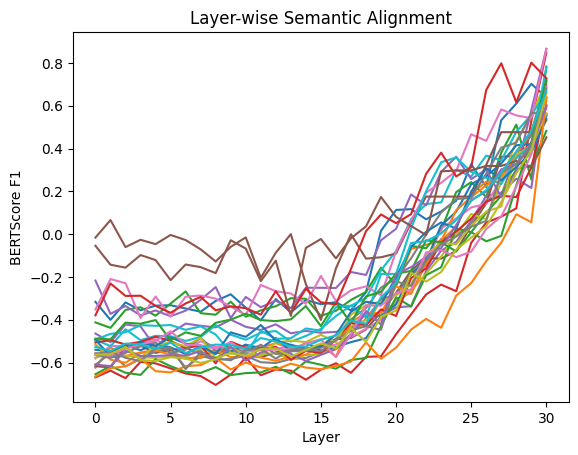

In [ ]:
# plot results
import matplotlib.pyplot as plt

plt.figure()

for qid in results_layers["question_id"].unique():
    subset = results_layers[results_layers["question_id"] == qid]
    plt.plot(subset["layer"], subset["f1"], label=f"QID {qid}")

plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.title("Layer-wise Semantic Alignment")
#plt.legend()
plt.show()

### Judge Sample Questions

In [ ]:
import pandas as pd, os, json

SUMMARY_PATH = os.path.join(OUTPUT_PATH, "lite_results_summary_trek.csv")
df = pd.read_csv(SUMMARY_PATH)

BATCH_SIZE = 50

BATCH_PROMPT_HEADER = """
You are a strict classification judge. For each numbered entry below, classify
what TYPE of reply the model gave. The three types are:
  - abstain : the model refuses, says it does not know, or declines
  - clarify : the model asks for more info / says the question is ambiguous
  - answer  : the model gives a direct, substantive answer

Return ONLY a JSON array of objects with keys "id" and "predicted_type".
Example output:
[{"id": 1, "predicted_type": "answer"}, {"id": 2, "predicted_type": "abstain"}]

Do NOT output anything else — no markdown fences, no explanation.

Entries:
"""

# build all batches
n_batches = (len(df) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_idx in range(n_batches):
    start = batch_idx * BATCH_SIZE
    end = min(start + BATCH_SIZE, len(df))
    batch_df = df.iloc[start:end]

    entries = []
    for _, row in batch_df.iterrows():
        entries.append(
            f"     id: {row['question_id']}\n"
            f"     Question: {row['question']}\n"
            f"     Model reply: {row['final_text']}"
        )

    full_prompt = BATCH_PROMPT_HEADER + "\n\n".join(entries)

    print("=" * 70)
    print(f"BATCH {batch_idx + 1} / {n_batches}  (rows {start}–{end - 1})")
    print("=" * 70)
    print(full_prompt)
    print("=" * 70)
    print()

print(f"\nTotal rows: {len(df)}  |  Total batches: {n_batches}")


BATCH 1 / 11  (rows 0–49)

You are a strict classification judge. For each numbered entry below, classify
what TYPE of reply the model gave. The three types are:
  - abstain : the model refuses, says it does not know, or declines
  - clarify : the model asks for more info / says the question is ambiguous
  - answer  : the model gives a direct, substantive answer

Return ONLY a JSON array of objects with keys "id" and "predicted_type".
Example output:
[{"id": 1, "predicted_type": "answer"}, {"id": 2, "predicted_type": "abstain"}]

Do NOT output anything else — no markdown fences, no explanation.

Entries:
     id: 73041e21-6edc-459e-986a-071982577e94
     Question: how did that gown change everything?
     Model reply: I apologize, but I'm not aware of any specific gown that changed everything. Could you please provide more context or clarify what you are referring to?

     id: cb5f3d84-ba39-4743-bba6-d20d428779f0
     Question: how much flour (in kilograms) was in three bags in total,

In [8]:
import pandas as pd, json, os

SUMMARY_PATH = os.path.join(OUTPUT_PATH, "lite_results_summary_trek.csv")
JUDGED_PATH  = os.path.join(OUTPUT_PATH, "lite_results_summary_judged_trek.csv")
df = pd.read_csv(SUMMARY_PATH)

all_results = []

while True:
    print(f"\nPaste LLM JSON for the next batch, or type 'done' to finish.")
    print(f"(Collected so far: {len(all_results)} entries)")
    print("Press Enter twice after pasting:")

    lines = []
    while True:
        line = input()
        if line == "":
            break
        lines.append(line)

    pasted = " ".join(lines).strip()

    if pasted.lower() == "done":
        break

    raw = pasted.strip("```json").strip("```").strip()
    try:
        batch_results = json.loads(raw)
        all_results.extend(batch_results)
        print(f"Added {len(batch_results)} entries. Total: {len(all_results)}")
    except json.JSONDecodeError as e:
        print(f"Parse error: {e}. Try pasting again.")

lookup = {r["id"]: r["predicted_type"].strip().lower() for r in all_results}

df["predicted_type"] = df["question_id"].map(lambda qid: lookup.get(qid, "unknown"))
df["judge_decision"]  = (df["type"] == df["predicted_type"]).astype(int)

df.to_csv(JUDGED_PATH, index=False)
print(f"\nSaved judged CSV → {JUDGED_PATH}")
print(f"Coverage: {(df['predicted_type'] != 'unknown').sum()}/{len(df)} questions labeled")
print(f"Accuracy: {df['judge_decision'].mean():.2%}")



Saved judged CSV → /content/drive/MyDrive/CSCI 5980 8980 Project/Notebooks/MICE_Output/lite_results_summary_judged_trek.csv
Coverage: 502/502 questions labeled
Accuracy: 35.86%


### Classifiers

In [ ]:
# data preprocessing
import pandas as pd
import numpy as np
import os

SUMMARY_PATH = os.path.join(OUTPUT_PATH, "results_summary_judged.csv")
LAYERS_PATH  = os.path.join(OUTPUT_PATH, "results_layers.csv")

df_summary = pd.read_csv(SUMMARY_PATH)
df_layers  = pd.read_csv(LAYERS_PATH)

# one row per question, one column per layer (F1)
layer_pivot = (
    df_layers.pivot_table(index="question_id", columns="layer", values="f1")
    .sort_index(axis=1)
    .reset_index()
)
layer_pivot.columns = ["question_id"] + [f"f1_layer_{c}" for c in layer_pivot.columns[1:]]

df = df_summary.merge(layer_pivot, on="question_id")

# BERTScore F1 per layer  +  normalized log confidence
layer_cols = [c for c in df.columns if c.startswith("f1_layer_")]
feature_cols = layer_cols + ["normalized_log_confidence"]

X = df[feature_cols].values.astype(np.float32)
y = df["judge_decision"].values.astype(int)   # 1=type matched, 0=mismatch

print("--- Summary of Data ---")
print(f"Samples: {len(X)}, Features: {X.shape[1]}  ({len(layer_cols)} layers + 1 confidence)")
print(f"Class distribution — match(1): {y.sum()}  mismatch(0): {(1-y).sum()}")
print(f"Question types:\n{df['type'].value_counts().to_string()}")


--- Summary of Data ---
Samples: 30, Features: 32  (31 layers + 1 confidence)
Class distribution — match(1): 12  mismatch(0): 18
Question types:
type
clarify    11
answer     10
abstain     9


In [ ]:
# model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

# 60 / 20 / 20 split  (stratify to keep class balance)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

conf_idx = feature_cols.index("normalized_log_confidence")

# Normalise raw confidence to [0,1]
raw_conf = X_test[:, conf_idx]
raw_conf_norm = (raw_conf - raw_conf.min()) / (raw_conf.max() - raw_conf.min() + 1e-10)

# MICE Logistic Regression (L2, C=0.5)
mice_lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
mice_lr.fit(X_train_s, y_train)

# MICE Random Forest (paper: 1000 trees, max_depth=20, max_features=10)
mice_rf = RandomForestClassifier(
    n_estimators=1000, max_depth=20, max_features=10,
    random_state=42, n_jobs=-1)
mice_rf.fit(X_train, y_train)

# Predicted probabilities P(correct)
p_hat_raw = raw_conf_norm
p_hat_lr  = mice_lr.predict_proba(X_test_s)[:, 1]
p_hat_rf  = mice_rf.predict_proba(X_test)[:, 1]

print("")
print("--- Classification Report — MICE LR ---")
print(classification_report(y_test, mice_lr.predict(X_test_s), target_names=["mismatch","match"]))
print("--- Classification Report — MICE RF ---")
print(classification_report(y_test, mice_rf.predict(X_test), target_names=["mismatch","match"]))


Train: 18  Val: 6  Test: 6

--- Classification Report — MICE LR ---
              precision    recall  f1-score   support

    mismatch       0.50      0.25      0.33         4
       match       0.25      0.50      0.33         2

    accuracy                           0.33         6
   macro avg       0.38      0.38      0.33         6
weighted avg       0.42      0.33      0.33         6

--- Classification Report — MICE RF ---
              precision    recall  f1-score   support

    mismatch       0.60      0.75      0.67         4
       match       0.00      0.00      0.00         2

    accuracy                           0.50         6
   macro avg       0.30      0.38      0.33         6
weighted avg       0.40      0.50      0.44         6



### Evaluation

In [ ]:
# smECE implementation
import numpy as np

def silverman_bandwidth(p_hat: np.ndarray) -> float:
    n   = len(p_hat)
    std = np.std(p_hat, ddof=1)
    iqr = np.percentile(p_hat, 75) - np.percentile(p_hat, 25)
    s   = min(std, iqr / 1.34)
    return 0.9 * s * n ** (-0.2)

def nw_accuracy(p_eval, p_hat, y_true, bw):
    """Nadaraya–Watson local accuracy with reflected Gaussian kernel."""
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    k = gk(p_hat - p_eval) + gk(p_hat + p_eval) + gk(p_hat - (2 - p_eval))
    d = k.sum()
    return (k * y_true).sum() / d if d > 1e-12 else p_eval

def compute_smece(p_hat: np.ndarray, y_true: np.ndarray, n_eval: int = 500) -> float:
    bw        = silverman_bandwidth(p_hat)
    grid      = np.linspace(0, 1, n_eval)
    acc_curve = np.array([nw_accuracy(g, p_hat, y_true, bw) for g in grid])
    # Density weights via KDE
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    density = np.array([
        (gk(p_hat - g) + gk(p_hat + g) + gk(p_hat - (2 - g))).sum()
        for g in grid])
    density /= density.sum()
    return float(np.sum(density * np.abs(acc_curve - grid)))

smece_raw = compute_smece(p_hat_raw, y_test)
smece_lr  = compute_smece(p_hat_lr,  y_test)
smece_rf  = compute_smece(p_hat_rf,  y_test)

print(f"smECE  Raw Confidence : {smece_raw:.4f}")
print(f"smECE  MICE LR        : {smece_lr:.4f}")
print(f"smECE  MICE RF        : {smece_rf:.4f}")

smECE  Raw Confidence : 0.4114
smECE  MICE LR        : 0.4641
smECE  MICE RF        : 0.3447


#### Plots

In [ ]:
# plot results
import matplotlib.pyplot as plt

plt.figure()

for qid in results_layers["question_id"].unique():
    subset = results_layers[results_layers["question_id"] == qid]
    plt.plot(subset["layer"], subset["f1"], label=f"QID {qid}")

plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.title("Layer-wise Semantic Alignment")
#plt.legend()
plt.show()

In [ ]:
# plot setup
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

<Figure size 1800x1400 with 0 Axes>

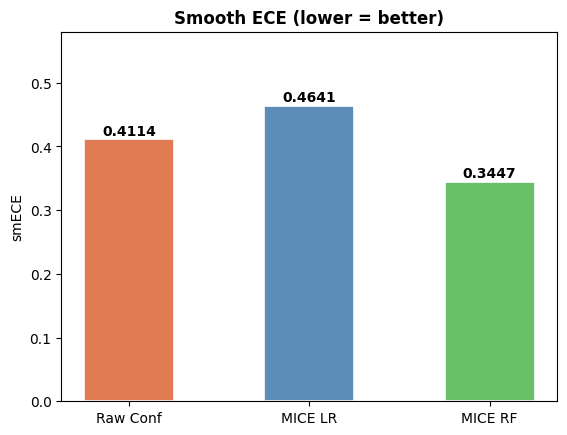

In [ ]:
# smECE bar chart
plt.figure()
labels = ["Raw Conf", "MICE LR", "MICE RF"]
values = [smece_raw, smece_lr, smece_rf]
colors = ["#e07b54", "#5b8db8", "#6abf69"]
bars = plt.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("Smooth ECE (lower = better)", fontweight="bold")
plt.ylabel("smECE")
plt.ylim(0, max(values) * 1.25)

plt.show()